# 📊 Sales Data — Exploratory Data Analysis

**Dataset:** `sales_data.csv`  
**Records:** 10,000 orders | **Period:** Jan – Dec 2025  
**Columns:** Order_ID, Date, Region, Salesperson, Category, Product, Quantity, Unit_Price, Sales, Profit


## 1. Setup & Data Loading

In [1]:
# Install dependencies as needed:
%%capture
!pip install kagglehub[pandas-datasets]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Aesthetics
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "arunkumaroraon/indian-sales-transactions-dataset-2025",
    "sales_data.csv"
)

df.head()

100%|██████████| 680k/680k [00:00<00:00, 2.04MB/s]


,Order_ID,Date,Region,Salesperson,Category,Product,Quantity,Unit_Price,Sales,Profit
0,ORD00001,2025-07-19,West,Sneha,Electronics,Laptop,12,50000,600000,83914
1,ORD00002,2025-08-13,West,Sneha,Furniture,Table,14,8000,112000,19810
2,ORD00003,2025-08-25,North,Amit,Electronics,Laptop,14,50000,700000,137261
3,ORD00004,2025-01-30,East,Arun,Electronics,Laptop,3,50000,150000,17069
4,ORD00005,2025-03-09,West,Rahul,Electronics,Laptop,17,50000,850000,248242


## 2. Dataset Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Order_ID     10000 non-null  object
 1   Date         10000 non-null  object
 2   Region       10000 non-null  object
 3   Salesperson  10000 non-null  object
 4   Category     10000 non-null  object
 5   Product      10000 non-null  object
 6   Quantity     10000 non-null  int64 
 7   Unit_Price   10000 non-null  int64 
 8   Sales        10000 non-null  int64 
 9   Profit       10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [5]:
# Missing values & duplicates
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values:
Order_ID       0
Date           0
Region         0
Salesperson    0
Category       0
Product        0
Quantity       0
Unit_Price     0
Sales          0
Profit         0
dtype: int64

Duplicate rows: 0


In [6]:
df.describe().round(2)

,Quantity,Unit_Price,Sales,Profit
count,10000.00,10000.00,10000.0,10000.00
mean,10.54,20007.00,210899.5,42114.73
std,5.74,15558.35,218146.0,46843.25
min,1.00,3000.00,3000.0,304.00
25%,6.00,8000.00,50000.0,9885.75
50%,11.00,20000.00,140000.0,25923.00
75%,16.00,25000.00,300000.0,55916.50
max,20.00,50000.00,1000000.0,298757.00


## 3. Feature Engineering

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter'] = df['Date'].dt.quarter.map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
df['Profit_Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)
print('New columns: Month, Month_Name, Quarter, Profit_Margin')
df[['Date','Month_Name','Quarter','Sales','Profit','Profit_Margin']].head()

New columns: Month, Month_Name, Quarter, Profit_Margin


,Date,Month_Name,Quarter,Sales,Profit,Profit_Margin
0,2025-07-19,Jul,Q3,600000,83914,13.99
1,2025-08-13,Aug,Q3,112000,19810,17.69
2,2025-08-25,Aug,Q3,700000,137261,19.61
3,2025-01-30,Jan,Q1,150000,17069,11.38
4,2025-03-09,Mar,Q1,850000,248242,29.20


## 4. Univariate Analysis

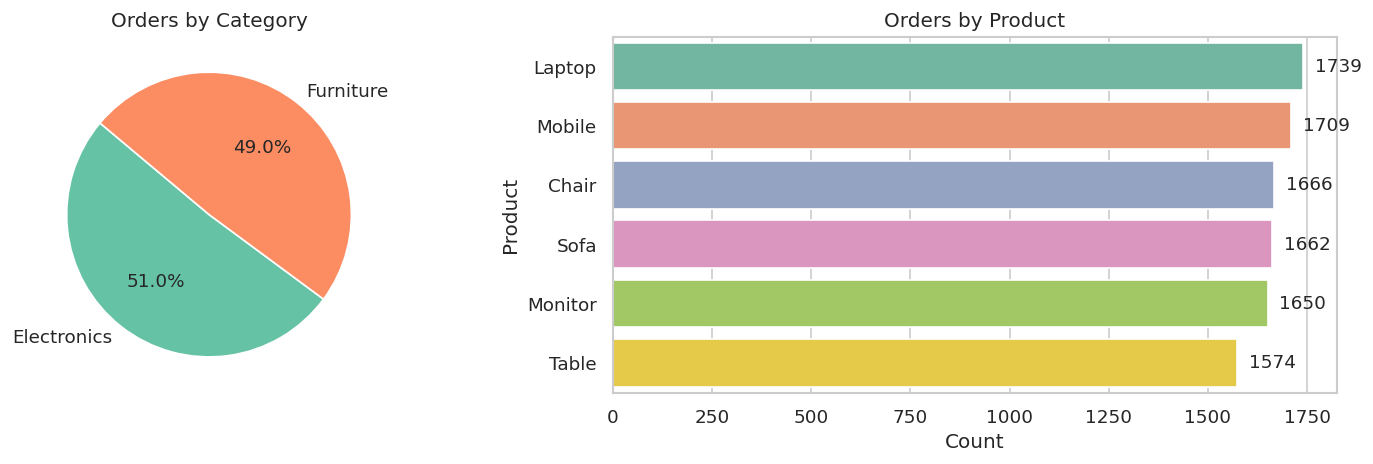

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Category mix
cat_counts = df['Category'].value_counts()
axes[0].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 2), startangle=140)
axes[0].set_title('Orders by Category')

# Product mix
prod_counts = df['Product'].value_counts()
sns.barplot(x=prod_counts.values, y=prod_counts.index, ax=axes[1],
            palette='Set2')
axes[1].set_title('Orders by Product')
axes[1].set_xlabel('Count')
for i, v in enumerate(prod_counts.values):
    axes[1].text(v + 30, i, str(v), va='center')

plt.tight_layout()
plt.show()

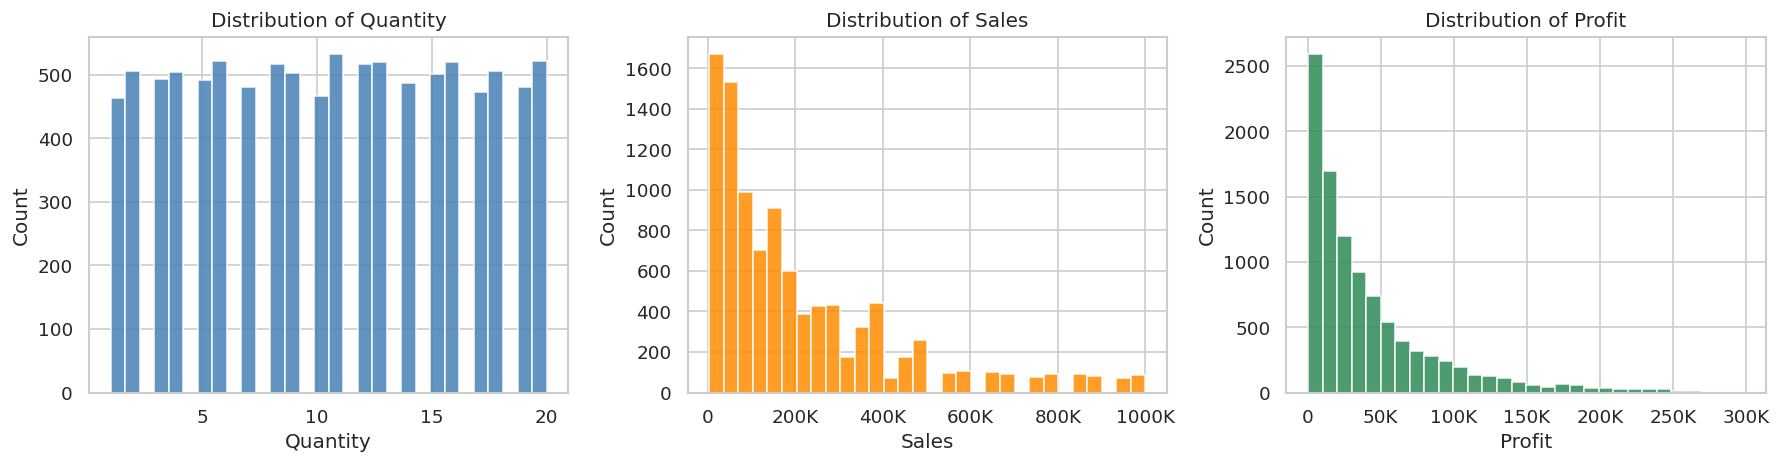

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Quantity','Sales','Profit'],
                            ['steelblue','darkorange','seagreen']):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else str(int(x))))
plt.tight_layout()
plt.show()

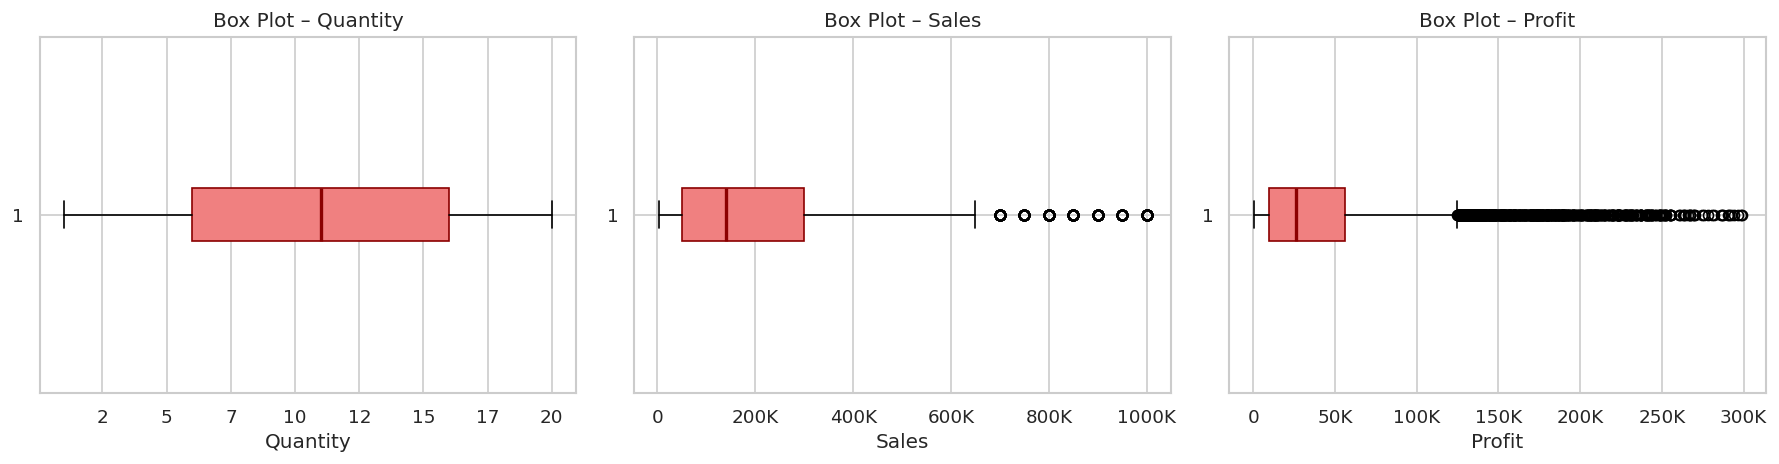

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Quantity','Sales','Profit']):
    ax.boxplot(df[col], vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightcoral', color='darkred'),
               medianprops=dict(color='darkred', linewidth=2))
    ax.set_title(f'Box Plot – {col}')
    ax.set_xlabel(col)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else str(int(x))))
plt.tight_layout()
plt.show()

## 5. Sales Trends Over Time

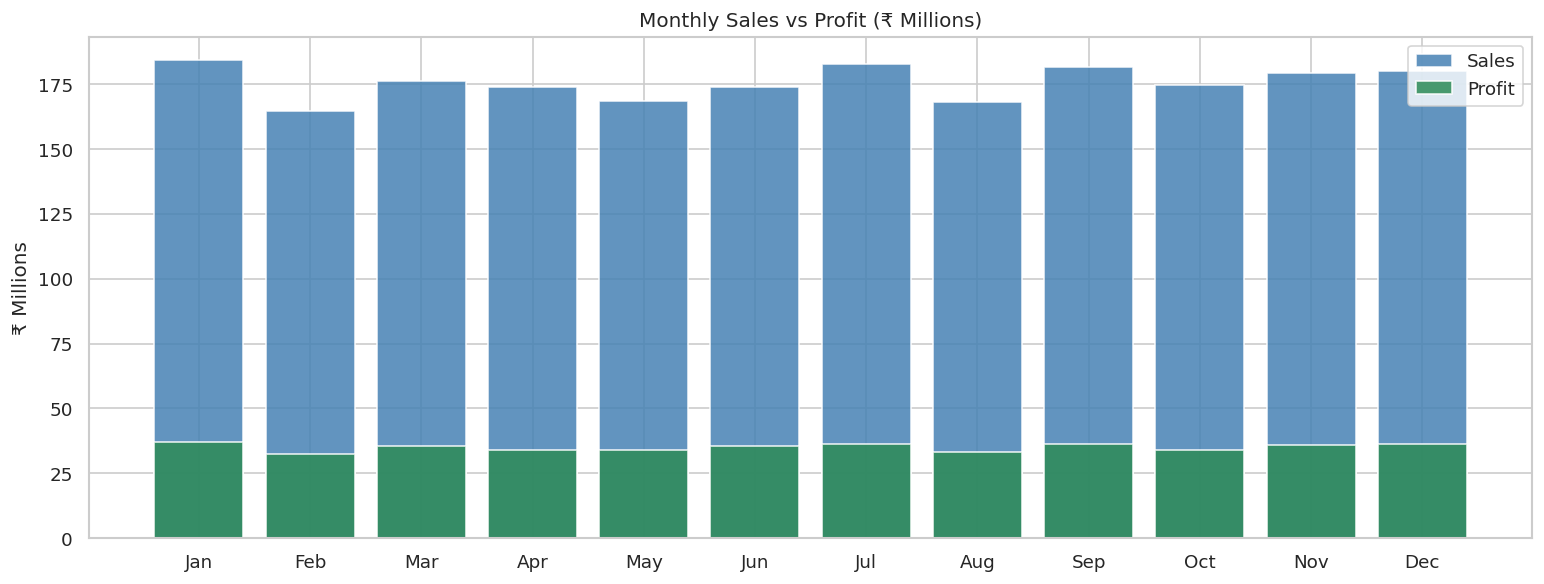

In [11]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = (df.groupby('Month_Name')[['Sales','Profit']]
             .sum().reindex(month_order) / 1e6)

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(monthly))
ax.bar(x, monthly['Sales'], label='Sales', color='steelblue', alpha=0.85)
ax.bar(x, monthly['Profit'], label='Profit', color='seagreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(month_order)
ax.set_title('Monthly Sales vs Profit (₹ Millions)')
ax.set_ylabel('₹ Millions')
ax.legend()
plt.tight_layout()
plt.show()

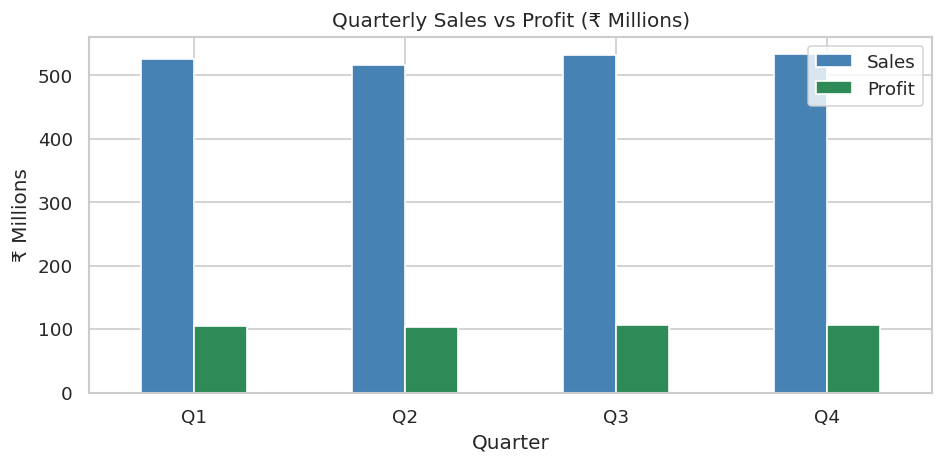

In [12]:
quarterly = df.groupby('Quarter')[['Sales','Profit']].sum() / 1e6
quarterly.plot(kind='bar', figsize=(8, 4), color=['steelblue','seagreen'],
               edgecolor='white', rot=0)
plt.title('Quarterly Sales vs Profit (₹ Millions)')
plt.ylabel('₹ Millions')
plt.tight_layout()
plt.show()

## 6. Regional Analysis

In [13]:
region_metrics = df.groupby('Region').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Orders=('Order_ID','count'),
    Avg_Margin=('Profit_Margin','mean')
).sort_values('Total_Sales', ascending=False).round(2)
region_metrics['Total_Sales_M'] = (region_metrics['Total_Sales']/1e6).round(2)
region_metrics['Total_Profit_M'] = (region_metrics['Total_Profit']/1e6).round(2)
region_metrics[['Total_Sales_M','Total_Profit_M','Orders','Avg_Margin']]

,Total_Sales_M,Total_Profit_M,Orders,Avg_Margin
Region,,,,
North,542.68,108.73,2528,20.04
East,528.94,105.82,2526,20.02
South,521.07,103.97,2482,19.97
West,516.30,102.64,2464,19.97


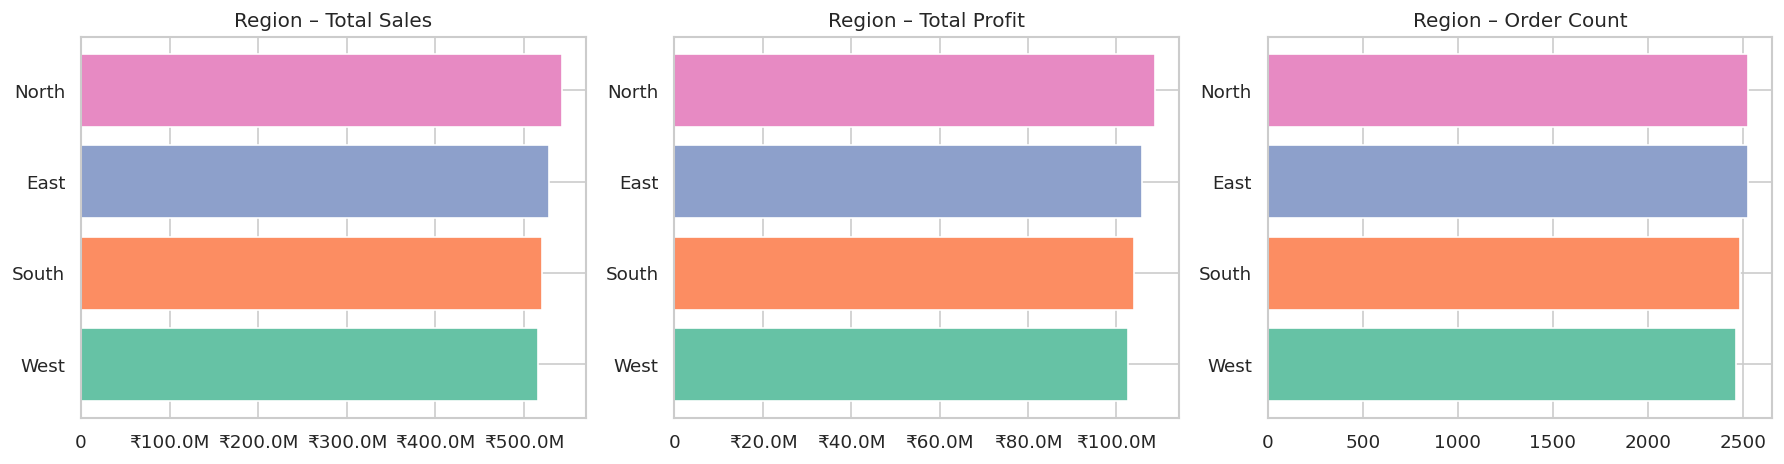

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
    ['Total_Sales','Total_Profit','Orders'],
    ['Total Sales','Total Profit','Order Count']):
    data = region_metrics[col].sort_values(ascending=True)
    ax.barh(data.index, data.values,
            color=sns.color_palette('Set2', len(data)))
    ax.set_title(f'Region – {title}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'₹{x/1e6:.1f}M' if x >= 1e6 else str(int(x))))
plt.tight_layout()
plt.show()

## 7. Salesperson Performance

In [15]:
sp = df.groupby('Salesperson').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order_ID','count'),
    Avg_Margin=('Profit_Margin','mean')
).sort_values('Sales', ascending=False).round(2)
sp['Sales_M'] = (sp['Sales']/1e6).round(2)
sp[['Sales_M','Profit','Orders','Avg_Margin']]

,Sales_M,Profit,Orders,Avg_Margin
Salesperson,,,,
Amit,200.67,40611110,914,20.17
Suresh,181.39,36578324,836,20.22
Priya,177.84,36060488,858,20.06
Arun,177.39,35301686,842,20.02
Anita,174.06,34266515,804,19.77
Rahul,173.18,34727789,830,20.35
Sneha,172.51,34332684,851,19.54
Raj,172.22,34570044,819,19.92
Meena,170.60,33577151,783,20.02


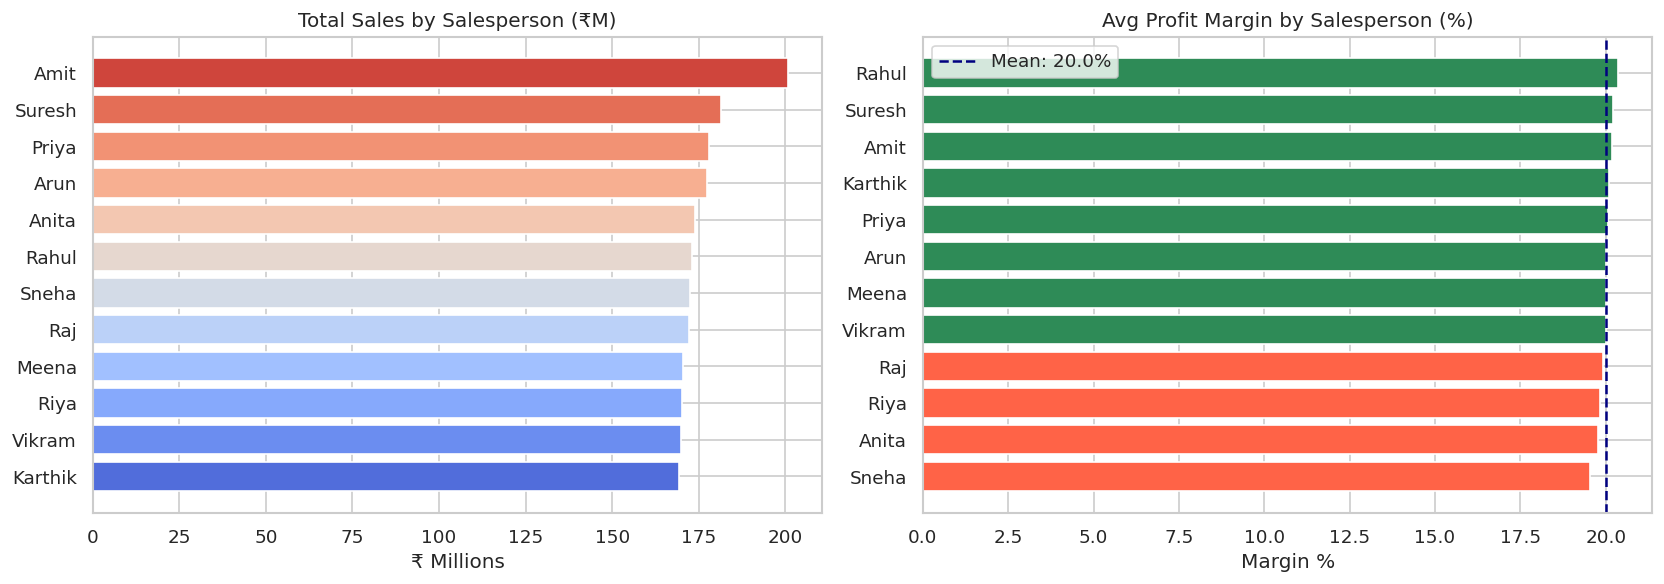

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sp_sorted = sp.sort_values('Sales')
axes[0].barh(sp_sorted.index, sp_sorted['Sales']/1e6,
             color=sns.color_palette('coolwarm', len(sp_sorted)))
axes[0].set_title('Total Sales by Salesperson (₹M)')
axes[0].set_xlabel('₹ Millions')

sp_sorted2 = sp.sort_values('Avg_Margin')
colors = ['seagreen' if m >= sp['Avg_Margin'].mean() else 'tomato'
          for m in sp_sorted2['Avg_Margin']]
axes[1].barh(sp_sorted2.index, sp_sorted2['Avg_Margin'], color=colors)
axes[1].axvline(sp['Avg_Margin'].mean(), color='navy', linestyle='--',
                label=f"Mean: {sp['Avg_Margin'].mean():.1f}%")
axes[1].set_title('Avg Profit Margin by Salesperson (%)')
axes[1].set_xlabel('Margin %')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Product & Category Analysis

In [17]:
prod = df.groupby(['Category','Product']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Units=('Quantity','sum'),
    Avg_Margin=('Profit_Margin','mean')
).sort_values('Sales', ascending=False).round(2)
prod['Sales_M'] = (prod['Sales']/1e6).round(2)
prod[['Sales_M','Profit','Units','Avg_Margin']]

Sales_M     Profit  Units  Avg_Margin
Category    Product                                       
Electronics Laptop    919.10  183253154  18382       19.93
Furniture   Sofa      440.82   87922374  17633       19.87
Electronics Mobile    354.54   70209300  17727       19.76
            Monitor   208.07   42128643  17339       20.11
Furniture   Table     133.63   27092488  16704       20.33
            Chair      52.83   10541364  17610       20.05

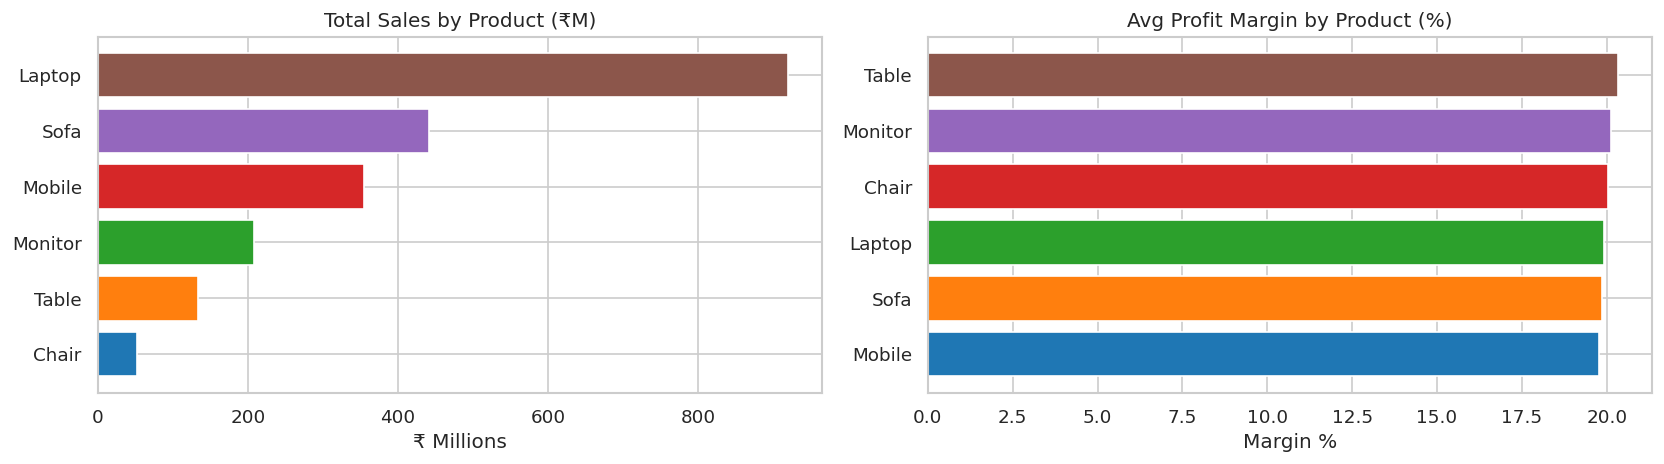

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

prod_flat = df.groupby('Product')['Sales'].sum().sort_values()
axes[0].barh(prod_flat.index, prod_flat.values/1e6,
             color=sns.color_palette('tab10', len(prod_flat)))
axes[0].set_title('Total Sales by Product (₹M)')
axes[0].set_xlabel('₹ Millions')

margin_prod = df.groupby('Product')['Profit_Margin'].mean().sort_values()
axes[1].barh(margin_prod.index, margin_prod.values,
             color=sns.color_palette('tab10', len(margin_prod)))
axes[1].set_title('Avg Profit Margin by Product (%)')
axes[1].set_xlabel('Margin %')

plt.tight_layout()
plt.show()

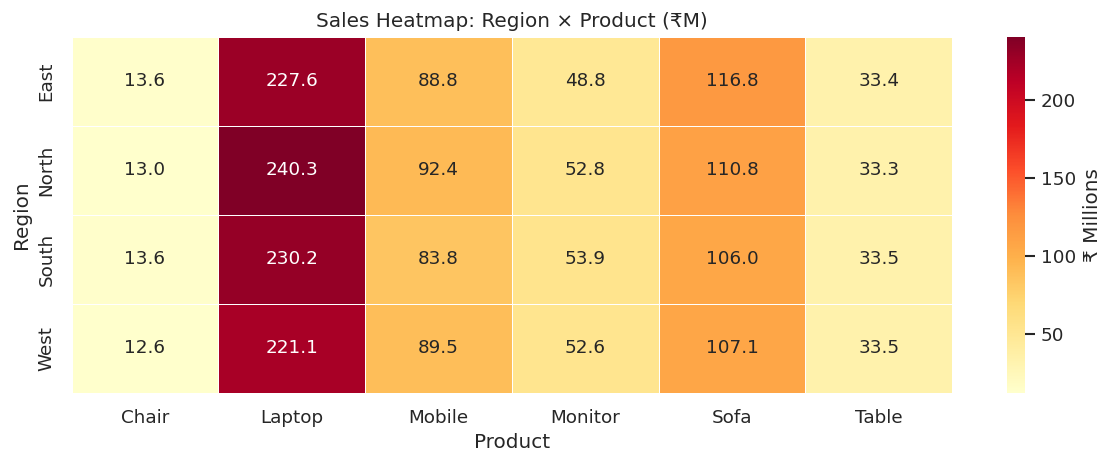

In [19]:
# Heatmap: Region x Product sales
pivot = df.pivot_table(values='Sales', index='Region',
                       columns='Product', aggfunc='sum') / 1e6
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '₹ Millions'})
ax.set_title('Sales Heatmap: Region × Product (₹M)')
plt.tight_layout()
plt.show()

## 9. Correlation & Bivariate Analysis

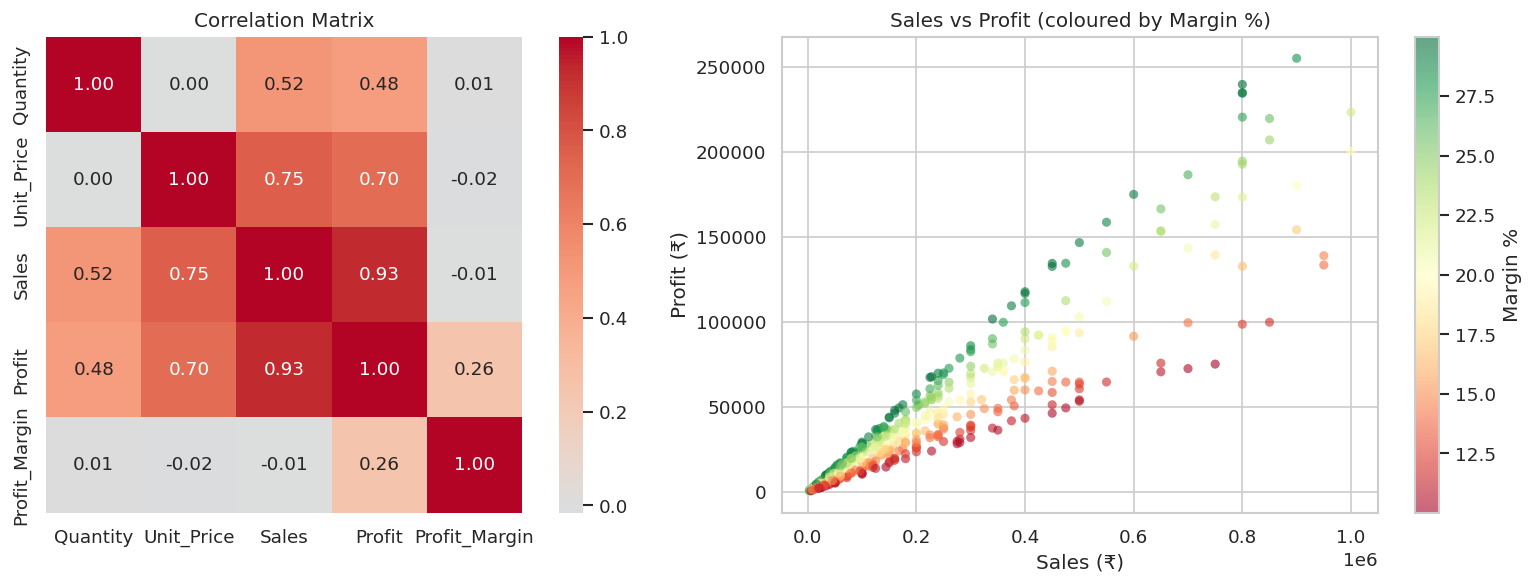

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df[['Quantity','Unit_Price','Sales','Profit','Profit_Margin']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], square=True)
axes[0].set_title('Correlation Matrix')

sample = df.sample(500, random_state=42)
axes[1].scatter(sample['Sales'], sample['Profit'],
                c=sample['Profit_Margin'], cmap='RdYlGn',
                alpha=0.6, edgecolors='none', s=30)
axes[1].set_title('Sales vs Profit (coloured by Margin %)')
axes[1].set_xlabel('Sales (₹)')
axes[1].set_ylabel('Profit (₹)')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Margin %')

plt.tight_layout()
plt.show()

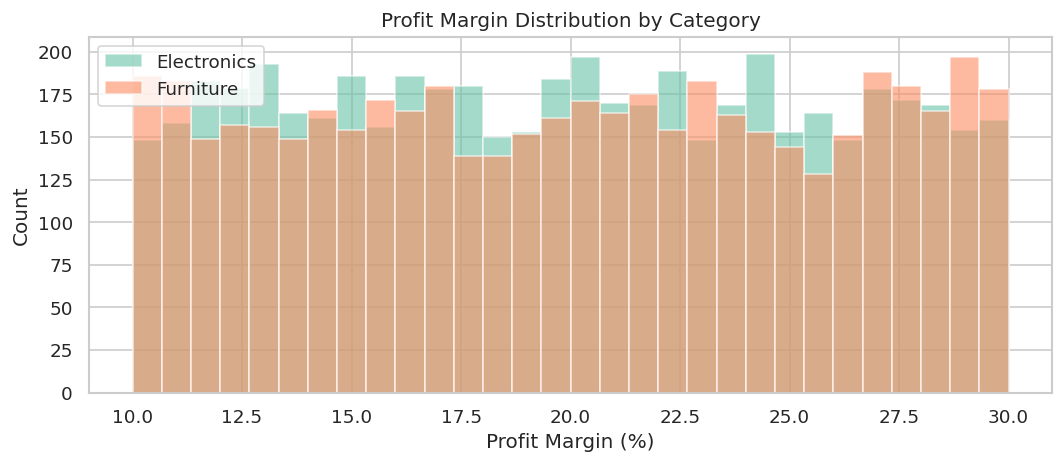

In [21]:
# Profit margin distribution by category
fig, ax = plt.subplots(figsize=(9, 4))
for cat, grp in df.groupby('Category'):
    ax.hist(grp['Profit_Margin'], bins=30, alpha=0.6, label=cat)
ax.set_title('Profit Margin Distribution by Category')
ax.set_xlabel('Profit Margin (%)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Top Performers

In [22]:
print('=== Top 10 Orders by Sales ===')
display(df.nlargest(10, 'Sales')[['Order_ID','Date','Region','Salesperson',
                                   'Product','Quantity','Sales','Profit','Profit_Margin']])
print('\n=== Top 10 Orders by Profit Margin ===')
display(df.nlargest(10, 'Profit_Margin')[['Order_ID','Date','Region','Salesperson',
                                           'Product','Quantity','Sales','Profit','Profit_Margin']])

=== Top 10 Orders by Sales ===


,Order_ID,Date,Region,Salesperson,Product,Quantity,Sales,Profit,Profit_Margin
164,ORD00165,2025-10-02,South,Karthik,Laptop,20,1000000,249845,24.98
454,ORD00455,2025-04-27,East,Riya,Laptop,20,1000000,182577,18.26
497,ORD00498,2025-12-11,South,Anita,Laptop,20,1000000,209386,20.94
582,ORD00583,2025-08-09,North,Amit,Laptop,20,1000000,200361,20.04
672,ORD00673,2025-09-08,West,Sneha,Laptop,20,1000000,203453,20.35
687,ORD00688,2025-08-03,East,Riya,Laptop,20,1000000,280385,28.04
694,ORD00695,2025-05-31,West,Meena,Laptop,20,1000000,152056,15.21
883,ORD00884,2025-02-16,East,Arun,Laptop,20,1000000,160565,16.06
1364,ORD01365,2025-11-28,South,Karthik,Laptop,20,1000000,245181,24.52
1481,ORD01482,2025-01-23,North,Raj,Laptop,20,1000000,132140,13.21



=== Top 10 Orders by Profit Margin ===


,Order_ID,Date,Region,Salesperson,Product,Quantity,Sales,Profit,Profit_Margin
2961,ORD02962,2025-12-25,North,Vikram,Monitor,15,180000,53999,30.00
3946,ORD03947,2025-05-25,South,Karthik,Sofa,18,450000,134991,30.00
4693,ORD04694,2025-12-27,West,Rahul,Laptop,12,600000,179943,29.99
4951,ORD04952,2025-12-13,East,Riya,Mobile,2,40000,11996,29.99
5429,ORD05430,2025-10-18,South,Karthik,Mobile,20,400000,119942,29.99
7204,ORD07205,2025-01-21,North,Amit,Mobile,8,160000,47981,29.99
8568,ORD08569,2025-01-19,West,Rahul,Table,17,136000,40787,29.99
9692,ORD09693,2025-05-31,West,Sneha,Sofa,2,50000,14997,29.99
3388,ORD03389,2025-05-07,South,Karthik,Table,1,8000,2398,29.98
4769,ORD04770,2025-05-22,North,Vikram,Laptop,12,600000,179909,29.98


## 11. Key Findings Summary

| Metric | Value |
|--------|-------|
| Total Orders | 10,000 |
| Period | Jan – Dec 2025 |
| Regions | 4 (North, South, East, West) |
| Salespersons | 12 |
| Products | 6 across 2 categories |

### Highlights
- **No missing values or duplicates** — dataset is clean.
- **Sales and Profit** are right-skewed, driven by high-value Electronics (Laptop) orders.
- **Electronics outperforms Furniture** in both revenue and volume.
- **Regional performance** varies; check the heatmap for product-level regional strengths.
- **Profit Margin** has moderate variability across salespersons — opportunity for coaching.
- **Monthly trends** reveal seasonal peaks; Q4 analysis can guide inventory planning.
